<a href="https://colab.research.google.com/github/ManhattanCB01-nyc/CrashVehiclesDataPipeline/blob/main/build_cb1_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Manhattan CB1 Motor Vehicle Collisions

Pulls the NYC [Motor Vehicle Collisions - Crashes](https://data.cityofnewyork.us/Public-Safety/Motor-Vehicle-Collisions-Crashes/h9gi-nx95/about_data)
dataset, keeps Manhattan crashes from **2018-01-01** onward, and spatially
confines them to **Community District 101 (Manhattan Community Board 1)**
using the actual CB1 polygon boundary from NYC's
[Community Districts](https://data.cityofnewyork.us/City-Government/Community-Districts/5crt-au7u)
dataset (a real point-in-polygon test on each crash's own lat/lon - not a
street-name, zip-code, or borough approximation).

Every output row is a single crash at its own original latitude/longitude.
Coordinates are never averaged, centroided, or otherwise aggregated.

The matching [Vehicles](https://data.cityofnewyork.us/Public-Safety/Motor-Vehicle-Collisions-Vehicles/bm4k-52h4/about_data) and [Person](https://data.cityofnewyork.us/Public-Safety/Motor-Vehicle-Collisions-Person/f55k-p6yu/about_data) records for those same CB1 `collision_id`s are pulled too, and all three tables are written to one Excel workbook as separate sheets: `Crashes`, `Vehicles`, `Persons`.

In [85]:
#!pip install google.colab

In [86]:
# --- Google API Imports ---
from google.oauth2 import service_account
from googleapiclient.discovery import build
from googleapiclient.errors import HttpError


In [87]:
from __future__ import annotations

import os

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import requests
from shapely.geometry import Point

In [88]:
import time

REQUEST_TIMEOUT = 200
MAX_RETRIES = 5
RETRY_BACKOFF_SECONDS = 5  # doubles each retry: 5, 10, 20, 40, 80


def _get_with_retries(endpoint: str, params: dict, headers: dict) -> requests.Response:
    """GET with retry/backoff so a single slow or dropped response from the
    Socrata API (common on large paginated pulls, especially from CI
    runners) doesn't kill the whole run."""
    last_exc = None
    for attempt in range(1, MAX_RETRIES + 1):
        try:
            resp = requests.get(endpoint, params=params, headers=headers, timeout=REQUEST_TIMEOUT)
            resp.raise_for_status()
            return resp
        except requests.exceptions.RequestException as exc:
            last_exc = exc
            if attempt == MAX_RETRIES:
                break
            wait = RETRY_BACKOFF_SECONDS * (2 ** (attempt - 1))
            print(f"    request failed ({exc.__class__.__name__}: {exc}); retrying in {wait}s (attempt {attempt}/{MAX_RETRIES})")
            time.sleep(wait)
    raise last_exc

In [89]:
try:
    from google.colab import drive
    COLAB_ENV = True
    print("Running in Google Colab environment.")
    drive.mount('/content/drive')
except ImportError:
    COLAB_ENV = False
    print("Not running in Google Colab environment.")

Running in Google Colab environment.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Config

In [90]:
COLLISIONS_ENDPOINT = "https://data.cityofnewyork.us/resource/h9gi-nx95.json"
VEHICLES_ENDPOINT = "https://data.cityofnewyork.us/resource/bm4k-52h4.json"
PERSONS_ENDPOINT = "https://data.cityofnewyork.us/resource/f55k-p6yu.json"
COMMUNITY_DISTRICTS_ENDPOINT = "https://data.cityofnewyork.us/resource/5crt-au7u.geojson"

START_DATE = "2018-01-01T00:00:00"
BOROUGH = "MANHATTAN"
CB1_BORO_CD = "101"  # borough digit 1 (Manhattan) + community district "01"

PAGE_SIZE = 5000
COLLISION_ID_BATCH_SIZE = 400  # keeps the $where IN (...) query string well under URL length limits

# When running in Colab, save under Google Drive (My Drive/manhattan_cb1_collisions/data)
# so the output survives after the runtime disconnects. Locally it still just uses ./data.
OUT_DIR = (
    "/content/drive/MyDrive/manhattan_cb1_collisions/data"
    if COLAB_ENV
    else "./data"
)
os.makedirs(OUT_DIR, exist_ok=True)

# Optional: set an app token to avoid anonymous Socrata rate limiting on a
# pull this size. Get one free at:
# https://data.cityofnewyork.us/profile/edit/developer_settings
APP_TOKEN = os.environ.get("NYC_OPEN_DATA_APP_TOKEN")  # or hardcode a string here

## Fetch Manhattan collisions (2018-01-01 onward)

Paginated SODA API pull. Rows without coordinates are dropped since they
can't be tested against the CB1 polygon.

In [91]:
def fetch_manhattan_collisions(app_token: str | None) -> pd.DataFrame:
    headers = {"X-App-Token": app_token} if app_token else {}
    where = (
        f"crash_date >= '{START_DATE}' "
        f"AND upper(borough) = '{BOROUGH}' "
        f"AND latitude IS NOT NULL AND longitude IS NOT NULL "
        f"AND latitude != 0.0 AND longitude != 0.0"
    )

    rows = []
    offset = 0
    while True:
        params = {
            "$where": where,
            "$order": "crash_date, collision_id",
            "$limit": PAGE_SIZE,
            "$offset": offset,
        }
        resp = _get_with_retries(COLLISIONS_ENDPOINT, params=params, headers=headers)
        batch = resp.json()
        if not batch:
            break
        rows.extend(batch)
        print(f"  fetched {len(rows):,} rows so far (offset={offset})")
        offset += PAGE_SIZE
        if len(batch) < PAGE_SIZE:
            break

    if not rows:
        raise RuntimeError("No collision records returned - check the API filters.")

    df = pd.DataFrame(rows)
    df["latitude"] = df["latitude"].astype(float)
    df["longitude"] = df["longitude"].astype(float)
    df["crash_date"] = pd.to_datetime(df["crash_date"])
    return df


collisions = fetch_manhattan_collisions(APP_TOKEN)
print(f"total {BOROUGH} rows with coordinates: {len(collisions):,}")
collisions.head()

  fetched 5,000 rows so far (offset=0)
  fetched 10,000 rows so far (offset=5000)
  fetched 15,000 rows so far (offset=10000)
  fetched 20,000 rows so far (offset=15000)
  fetched 25,000 rows so far (offset=20000)
  fetched 30,000 rows so far (offset=25000)
  fetched 35,000 rows so far (offset=30000)
  fetched 40,000 rows so far (offset=35000)
  fetched 45,000 rows so far (offset=40000)
  fetched 50,000 rows so far (offset=45000)
  fetched 55,000 rows so far (offset=50000)
  fetched 60,000 rows so far (offset=55000)
  fetched 65,000 rows so far (offset=60000)
  fetched 70,000 rows so far (offset=65000)
  fetched 75,000 rows so far (offset=70000)
  fetched 80,000 rows so far (offset=75000)
  fetched 85,000 rows so far (offset=80000)
  fetched 90,000 rows so far (offset=85000)
  fetched 95,000 rows so far (offset=90000)
  fetched 100,000 rows so far (offset=95000)
  fetched 105,000 rows so far (offset=100000)
  fetched 110,000 rows so far (offset=105000)
  fetched 115,000 rows so far (of

,crash_date,crash_time,borough,zip_code,latitude,longitude,location,on_street_name,off_street_name,number_of_persons_injured,...,collision_id,vehicle_type_code1,vehicle_type_code2,cross_street_name,contributing_factor_vehicle_3,vehicle_type_code_3,contributing_factor_vehicle_4,vehicle_type_code_4,contributing_factor_vehicle_5,vehicle_type_code_5
0,2018-01-01,2:45,MANHATTAN,10027,40.810173,-73.95117,"{'latitude': '40.810173', 'longitude': '-73.95...",WEST 125 STREET,8 AVENUE,1,...,3818619,Sedan,Sedan,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2018-01-01,11:45,MANHATTAN,10022,40.757404,-73.96872,"{'latitude': '40.757404', 'longitude': '-73.96...",NaN,NaN,0,...,3818660,Sedan,Station Wagon/Sport Utility Vehicle,222 EAST 53 STREET,NaN,NaN,NaN,NaN,NaN,NaN
2,2018-01-01,16:50,MANHATTAN,10005,40.708115,-74.00877,"{'latitude': '40.708115', 'longitude': '-74.00...",NaN,NaN,0,...,3818838,Sedan,Station Wagon/Sport Utility Vehicle,28 LIBERTY STREET,NaN,NaN,NaN,NaN,NaN,NaN
3,2018-01-01,10:33,MANHATTAN,10038,40.713444,-73.99854,"{'latitude': '40.713444', 'longitude': '-73.99...",PARK ROW,WORTH STREET,0,...,3818849,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2018-01-01,15:00,MANHATTAN,10006,40.709496,-74.01390,"{'latitude': '40.709496', 'longitude': '-74.01...",ALBANY STREET,WASHINGTON STREET,0,...,3818940,Taxi,Taxi,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Fetch the Manhattan CB1 polygon

In [92]:
def fetch_cb1_polygon(app_token: str | None) -> gpd.GeoDataFrame:
    headers = {"X-App-Token": app_token} if app_token else {}
    params = {"$where": f"boro_cd = '{CB1_BORO_CD}'"}
    resp = _get_with_retries(COMMUNITY_DISTRICTS_ENDPOINT, params=params, headers=headers)
    gdf = gpd.GeoDataFrame.from_features(resp.json()["features"], crs="EPSG:4326")
    if gdf.empty:
        raise RuntimeError(f"No community district polygon found for boro_cd={CB1_BORO_CD}")
    return gdf


cb1_polygon = fetch_cb1_polygon(APP_TOKEN)
cb1_polygon

,geometry,boro_cd,shape_leng,shape_area
0,"MULTIPOLYGON (((-74.04388 40.69019, -74.04351 ...",101,69433.3949824,41697039.426


## Confine each crash to CB1 (point-in-polygon, no averaging)

One `Point(longitude, latitude)` per crash, built directly from that
crash's own coordinates, then kept only if it falls `within` the CB1
polygon.

In [93]:
def confine_to_cb1(collisions: pd.DataFrame, cb1_polygon: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    geometry = [Point(lon, lat) for lon, lat in zip(collisions["longitude"], collisions["latitude"])]
    points = gpd.GeoDataFrame(collisions, geometry=geometry, crs="EPSG:4326")

    within_cb1 = gpd.sjoin(points, cb1_polygon[["geometry"]], how="inner", predicate="within")
    within_cb1 = within_cb1.drop(columns=["index_right"])
    return within_cb1


cb1_collisions = confine_to_cb1(collisions, cb1_polygon)
print(f"crashes inside CB1: {len(cb1_collisions):,}")
cb1_collisions.head()

crashes inside CB1: 8,244


,crash_date,crash_time,borough,zip_code,latitude,longitude,location,on_street_name,off_street_name,number_of_persons_injured,...,vehicle_type_code1,vehicle_type_code2,cross_street_name,contributing_factor_vehicle_3,vehicle_type_code_3,contributing_factor_vehicle_4,vehicle_type_code_4,contributing_factor_vehicle_5,vehicle_type_code_5,geometry
2,2018-01-01,16:50,MANHATTAN,10005,40.708115,-74.00877,"{'latitude': '40.708115', 'longitude': '-74.00...",NaN,NaN,0,...,Sedan,Station Wagon/Sport Utility Vehicle,28 LIBERTY STREET,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-74.00877 40.70812)
4,2018-01-01,15:00,MANHATTAN,10006,40.709496,-74.01390,"{'latitude': '40.709496', 'longitude': '-74.01...",ALBANY STREET,WASHINGTON STREET,0,...,Taxi,Taxi,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-74.0139 40.7095)
13,2018-01-01,3:30,MANHATTAN,10013,40.719395,-74.00189,"{'latitude': '40.719395', 'longitude': '-74.00...",CANAL STREET,BROADWAY,0,...,Station Wagon/Sport Utility Vehicle,Chassis Cab,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-74.00189 40.7194)
14,2018-01-01,2:00,MANHATTAN,10013,40.719448,-74.01030,"{'latitude': '40.719448', 'longitude': '-74.01...",GREENWICH STREET,FRANKLIN STREET,0,...,Sedan,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-74.0103 40.71945)
16,2018-01-01,3:36,MANHATTAN,10013,40.718273,-74.00533,"{'latitude': '40.718273', 'longitude': '-74.00...",CHURCH STREET,FRANKLIN STREET,0,...,Station Wagon/Sport Utility Vehicle,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-74.00533 40.71827)


## Sanity-check plot

CB1 boundary with every individual crash point plotted at its own
coordinates.

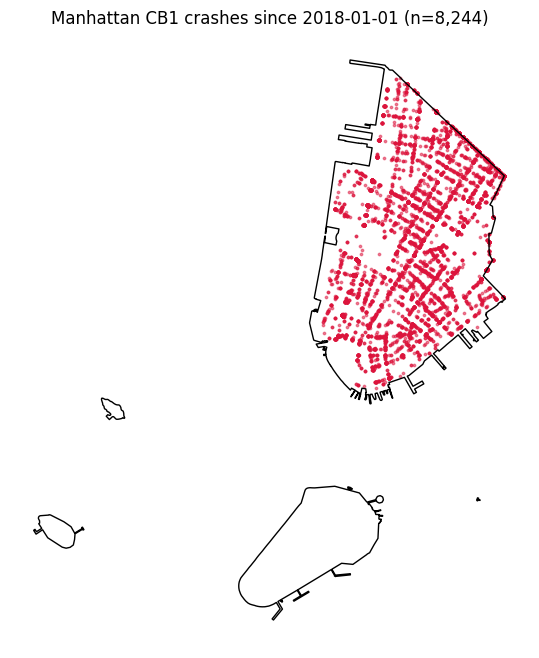

In [94]:
fig, ax = plt.subplots(figsize=(8, 8))
cb1_polygon.boundary.plot(ax=ax, color="black", linewidth=1)
cb1_collisions.plot(ax=ax, markersize=3, alpha=0.5, color="crimson")
ax.set_title(f"Manhattan CB1 crashes since {START_DATE[:10]} (n={len(cb1_collisions):,})")
ax.set_axis_off()
plt.show()

## Save crash outputs (CSV + GeoJSON)

In [95]:
csv_path = os.path.join(OUT_DIR, "manhattan_cb1_collisions_2018plus.csv")
geojson_path = os.path.join(OUT_DIR, "manhattan_cb1_collisions_2018plus.geojson")

cb1_crashes = cb1_collisions.drop(columns="geometry")
cb1_crashes.to_csv(csv_path, index=False)
cb1_collisions.to_file(geojson_path, driver="GeoJSON")

print(f"Wrote {len(cb1_crashes):,} individual crash records to:")
print(f"  {csv_path}")
print(f"  {geojson_path}")
cb1_crashes.head()

Wrote 8,244 individual crash records to:
  /content/drive/MyDrive/manhattan_cb1_collisions/data/manhattan_cb1_collisions_2018plus.csv
  /content/drive/MyDrive/manhattan_cb1_collisions/data/manhattan_cb1_collisions_2018plus.geojson


,crash_date,crash_time,borough,zip_code,latitude,longitude,location,on_street_name,off_street_name,number_of_persons_injured,...,collision_id,vehicle_type_code1,vehicle_type_code2,cross_street_name,contributing_factor_vehicle_3,vehicle_type_code_3,contributing_factor_vehicle_4,vehicle_type_code_4,contributing_factor_vehicle_5,vehicle_type_code_5
2,2018-01-01,16:50,MANHATTAN,10005,40.708115,-74.00877,"{'latitude': '40.708115', 'longitude': '-74.00...",NaN,NaN,0,...,3818838,Sedan,Station Wagon/Sport Utility Vehicle,28 LIBERTY STREET,NaN,NaN,NaN,NaN,NaN,NaN
4,2018-01-01,15:00,MANHATTAN,10006,40.709496,-74.01390,"{'latitude': '40.709496', 'longitude': '-74.01...",ALBANY STREET,WASHINGTON STREET,0,...,3818940,Taxi,Taxi,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13,2018-01-01,3:30,MANHATTAN,10013,40.719395,-74.00189,"{'latitude': '40.719395', 'longitude': '-74.00...",CANAL STREET,BROADWAY,0,...,3819574,Station Wagon/Sport Utility Vehicle,Chassis Cab,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14,2018-01-01,2:00,MANHATTAN,10013,40.719448,-74.01030,"{'latitude': '40.719448', 'longitude': '-74.01...",GREENWICH STREET,FRANKLIN STREET,0,...,3819730,Sedan,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16,2018-01-01,3:36,MANHATTAN,10013,40.718273,-74.00533,"{'latitude': '40.718273', 'longitude': '-74.00...",CHURCH STREET,FRANKLIN STREET,0,...,3820077,Station Wagon/Sport Utility Vehicle,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Fetch matching Vehicles & Person records

Pull every record from the Vehicles and Person datasets whose `collision_id` matches one of our CB1 crashes - exact ID matching, no fuzzy joins, no aggregation. IDs are queried in batches to keep the SoQL `IN (...)` query string short.

In [96]:
def fetch_by_collision_ids(endpoint: str, collision_ids: list[str], app_token: str | None) -> pd.DataFrame:
    headers = {"X-App-Token": app_token} if app_token else {}
    frames = []

    for start in range(0, len(collision_ids), COLLISION_ID_BATCH_SIZE):
        batch = collision_ids[start : start + COLLISION_ID_BATCH_SIZE]
        where = f"collision_id IN ({','.join(batch)})"

        offset = 0
        while True:
            params = {"$where": where, "$limit": PAGE_SIZE, "$offset": offset}
            resp = _get_with_retries(endpoint, params=params, headers=headers)
            page = resp.json()
            if not page:
                break
            frames.append(pd.DataFrame(page))
            offset += PAGE_SIZE
            if len(page) < PAGE_SIZE:
                break

    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True)


cb1_collision_ids = cb1_crashes["collision_id"].astype(str).unique().tolist()

print(f"Fetching Vehicles records for {len(cb1_collision_ids):,} CB1 collision_ids ...")
cb1_vehicles = fetch_by_collision_ids(VEHICLES_ENDPOINT, cb1_collision_ids, APP_TOKEN)
print(f"  vehicle records matched: {len(cb1_vehicles):,}")

print(f"Fetching Person records for {len(cb1_collision_ids):,} CB1 collision_ids ...")
cb1_persons = fetch_by_collision_ids(PERSONS_ENDPOINT, cb1_collision_ids, APP_TOKEN)
print(f"  person records matched: {len(cb1_persons):,}")

Fetching Vehicles records for 8,244 CB1 collision_ids ...
  vehicle records matched: 15,702
Fetching Person records for 8,244 CB1 collision_ids ...
  person records matched: 27,845


## Write the Excel workbook (one sheet per dataset)

`Crashes`, `Vehicles`, and `Persons` all share the same `collision_id` values, so they can be cross-referenced/joined directly in Excel or Power BI.

In [97]:
excel_path = os.path.join(OUT_DIR, "manhattan_cb1_collisions_2018plus.xlsx")

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    cb1_crashes.to_excel(writer, sheet_name="Crashes", index=False)
    cb1_vehicles.to_excel(writer, sheet_name="Vehicles", index=False)
    cb1_persons.to_excel(writer, sheet_name="Persons", index=False)

print(
    f"Wrote {excel_path} with sheets: "
    f"Crashes ({len(cb1_crashes):,} rows), "
    f"Vehicles ({len(cb1_vehicles):,} rows), "
    f"Persons ({len(cb1_persons):,} rows) - all matched on collision_id"
)

Wrote /content/drive/MyDrive/manhattan_cb1_collisions/data/manhattan_cb1_collisions_2018plus.xlsx with sheets: Crashes (8,244 rows), Vehicles (15,702 rows), Persons (27,845 rows) - all matched on collision_id


## Resources

- [Motor Vehicle Collisions - Crashes](https://data.cityofnewyork.us/Public-Safety/Motor-Vehicle-Collisions-Crashes/h9gi-nx95/about_data)
- [Motor Vehicle Collisions - Vehicles](https://data.cityofnewyork.us/Public-Safety/Motor-Vehicle-Collisions-Vehicles/bm4k-52h4/about_data)
- [Motor Vehicle Collisions - Person](https://data.cityofnewyork.us/Public-Safety/Motor-Vehicle-Collisions-Person/f55k-p6yu/about_data)
- [Community Districts](https://data.cityofnewyork.us/City-Government/Community-Districts/5crt-au7u/about_data)

## Save to Google BigQuery

Now, let's save the three DataFrames (`cb1_crashes`, `cb1_vehicles`, and `cb1_persons`) to Google BigQuery as separate tables within a specified project and dataset.

In [98]:
if COLAB_ENV:
    SERVICE_ACCOUNT_KEY_FILE = "/content/drive/Shareddrives/311_Complaint_Data/service_account_key.json"
else:
    SERVICE_ACCOUNT_KEY_FILE = "service_account_key.json"

In [105]:
try:
        creds = service_account.Credentials.from_service_account_file(
            SERVICE_ACCOUNT_KEY_FILE,
            scopes=["https://www.googleapis.com/auth/cloud-platform", "https://www.googleapis.com/auth/drive"]
        )
        print("Authentication successful.")
except Exception as e:
        print(f"FATAL: Authentication failed: {e}")


Authentication successful.


In [106]:

PROJECT_ID = 'stable-liberty-426016-d2'
DATASET_ID = 'new_dataset'

In [107]:

try:
    from google.colab import auth
    auth.authenticate_user()
except ImportError:
    COLAB_ENV = False
    print("Not running in Google Colab environment.")

In [108]:
import pandas_gbq



# Create the dataset in BigQuery if it doesn't exist
# This step requires BigQuery Data Editor or BigQuery Admin role
# The dataset will be created in the default location 'US' if not specified
from google.cloud import bigquery
client = bigquery.Client(project=PROJECT_ID)

try:
    client.get_dataset(DATASET_ID)
    print(f"Dataset '{DATASET_ID}' already exists.")
except Exception:
    dataset = bigquery.Dataset(f"{PROJECT_ID}.{DATASET_ID}")
    dataset.location = "US" # You can specify a different location if needed
    dataset = client.create_dataset(dataset, timeout=200)
    print(f"Dataset '{DATASET_ID}' created.")


print(f"Uploading 'Crashes' data to BigQuery table {DATASET_ID}.crashes...")
pandas_gbq.to_gbq(
    cb1_crashes,
    destination_table=f"{DATASET_ID}.crashes",
    project_id=PROJECT_ID,
    if_exists='replace', # 'fail', 'replace', or 'append'
    progress_bar=False
)
print(f"'Crashes' data uploaded: {len(cb1_crashes):,} rows")

print(f"Uploading 'Vehicles' data to BigQuery table {DATASET_ID}.vehicles...")
pandas_gbq.to_gbq(
    cb1_vehicles,
    destination_table=f"{DATASET_ID}.vehicles",
    project_id=PROJECT_ID,
    if_exists='replace',
    progress_bar=False
)
print(f"'Vehicles' data uploaded: {len(cb1_vehicles):,} rows")

print(f"Uploading 'Persons' data to BigQuery table {DATASET_ID}.persons...")
pandas_gbq.to_gbq(
    cb1_persons,
    destination_table=f"{DATASET_ID}.persons",
    project_id=PROJECT_ID,
    if_exists='replace',
    progress_bar=False
)
print(f"'Persons' data uploaded: {len(cb1_persons):,} rows")

Dataset 'new_dataset' already exists.
Uploading 'Crashes' data to BigQuery table new_dataset.crashes...
'Crashes' data uploaded: 8,244 rows
Uploading 'Vehicles' data to BigQuery table new_dataset.vehicles...
'Vehicles' data uploaded: 15,702 rows
Uploading 'Persons' data to BigQuery table new_dataset.persons...
'Persons' data uploaded: 27,845 rows
